In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/META.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


In [2]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df = df.dropna()

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2923 entries, 0 to 2922
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2923 non-null   datetime64[us]
 1   Close   2923 non-null   float64       
 2   High    2923 non-null   float64       
 3   Low     2923 non-null   float64       
 4   Open    2923 non-null   float64       
 5   Volume  2923 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 137.1 KB


In [4]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,2923,2923.000000,2923.000000,2923.000000,2923.000000,2.923000e+03
mean,2018-03-10 16:42:31.898734,156.727440,158.690484,154.685098,156.653626,3.060615e+07
min,2012-05-18 00:00:00,17.621368,18.158061,17.442471,17.969224,5.467500e+06
25%,2015-04-16 12:00:00,80.275124,80.970839,79.663892,80.275126,1.633730e+07
50%,2018-03-12 00:00:00,152.579376,154.636700,150.730785,152.698669,2.295390e+07
75%,2021-02-03 12:00:00,203.550171,206.372783,200.548679,202.963782,3.522740e+07
max,2023-12-29 00:00:00,379.838379,381.975166,376.488998,379.341431,5.735764e+08
std,NaN,90.368766,91.470736,89.222981,90.308834,2.637157e+07


In [5]:
# moving average
#SMA
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()
#EMA
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()


In [6]:
# RSI
import ta

df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()

In [7]:
# MACD
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

Visualization

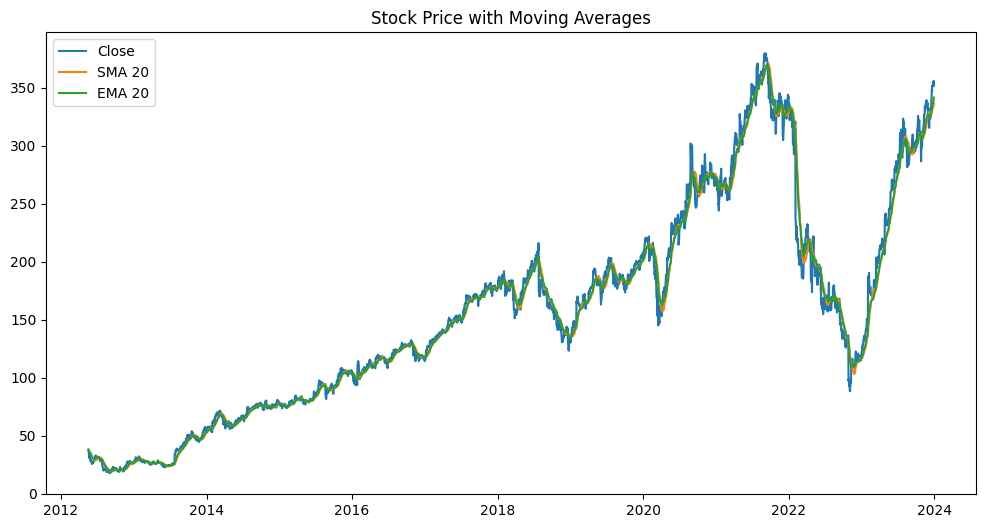

In [8]:
# Price and moving average

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')

plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

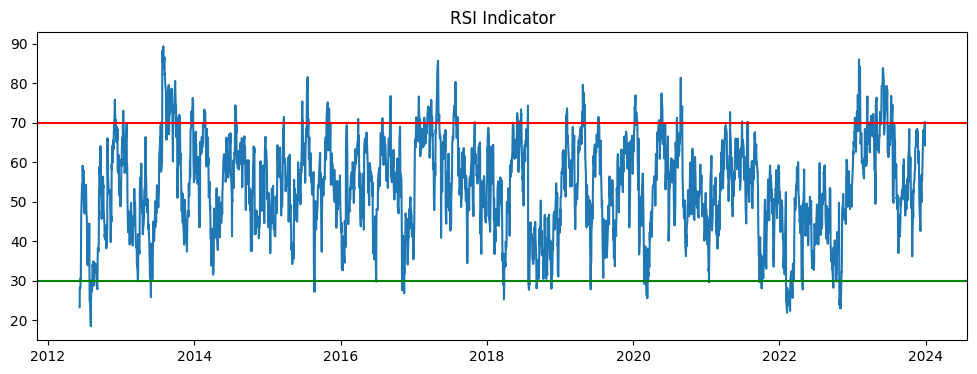

In [9]:
# RSI plot 
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['RSI'])

plt.axhline(70, color='red')
plt.axhline(30, color='green')

plt.title("RSI Indicator")
plt.show()

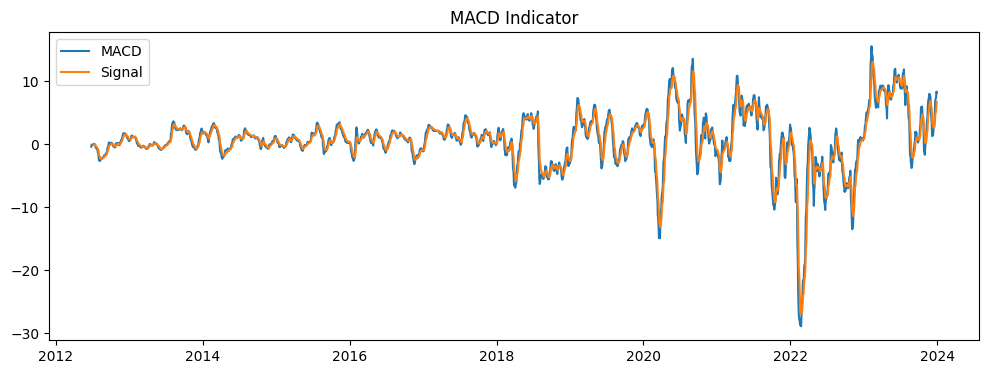

In [10]:
# MACD Plot
plt.figure(figsize=(12,4))

plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_signal'], label='Signal')

plt.legend()
plt.title("MACD Indicator")
plt.show()

In [11]:

df['returns'] = df['Close'].pct_change()
df['volatility'] = df['returns'].rolling(20).std()
df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1))

In [12]:
df.tail()

,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_signal,returns,volatility,log_returns
2918,2023-12-22,351.224823,355.011477,349.068105,353.401377,11772800,332.302945,323.317843,335.581703,67.333885,6.945367,4.729907,-0.001977,0.016090,-0.001979
2919,2023-12-26,352.655975,354.792827,351.284456,352.814999,9898600,333.303278,324.115724,337.207824,68.187000,7.436800,5.271285,0.004075,0.015809,0.004066
2920,2023-12-27,355.637543,356.800387,353.132994,353.888347,13207900,334.239505,324.844828,338.963036,69.947874,7.974921,5.812012,0.008455,0.015697,0.008419
2921,2023-12-28,356.124634,359.682686,355.617749,357.496184,11798800,335.537503,325.527023,340.597473,70.237702,8.344500,6.318510,0.001370,0.014758,0.001369
2922,2023-12-29,351.791290,357.794292,349.664418,356.790470,14987100,336.869788,326.262290,341.663551,64.296803,8.193282,6.693464,-0.012168,0.014566,-0.012243


In [13]:
df.to_csv("../data/META_processed.csv")